In [3]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from collections import Counter

# 1. Load dataset
df = pd.read_csv("full_data_unhealthy_imputed_reduced_enhanced.csv")

targets = ['oestrus', 'calving', 'lameness', 'mastitis']
features = ['IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'hour_bin']

# 2. Feature engineering function
def create_features(X):
    X = X.copy()
    # Cyclical time features
    X['hour_sin'] = np.sin(2 * np.pi * X['hour_bin'] / 24)
    X['hour_cos'] = np.cos(2 * np.pi * X['hour_bin'] / 24)
    # Ratios
    X['eat_rest_ratio'] = X['EAT'] / (X['REST'] + 1e-6)
    X['activity_rest_ratio'] = np.abs(X['ACTIVITY_LEVEL']) / (X['REST'] + 1e-6)
    return X.drop(columns=['hour_bin'])

# 3. Prepare X, y
X = df[features]
y = df[targets]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply feature engineering to training data before oversampling
X_train_eng = create_features(X_train)

# Apply ADASYN for each target separately and then merge
adasyn = ADASYN(sampling_strategy=0.25, random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train_eng, y_train['calving'])

# Note: ADASYN works for binary classification. 
# We'll resample for *each target separately* when training individual models
# OR you can run it per disease before MultiOutputClassifier.

# 4. Pipeline with MultiOutput Random Forest
pipeline = Pipeline([
    ('features', FunctionTransformer(create_features)),
    ('clf', MultiOutputClassifier(RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )))
])

# 5. Train on full training data (MultiOutputClassifier handles all labels)
pipeline.fit(X_train, y_train)

# 6. Evaluate
y_pred = pipeline.predict(X_test)
print("\nTest Performance:")
for i, target in enumerate(targets):
    print(f"\n{target}:")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



Test Performance:

oestrus:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     63393
           1       0.04      0.09      0.05       241

    accuracy                           0.99     63634
   macro avg       0.52      0.54      0.52     63634
weighted avg       0.99      0.99      0.99     63634


calving:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63497
           1       0.09      0.12      0.10       137

    accuracy                           1.00     63634
   macro avg       0.54      0.56      0.55     63634
weighted avg       1.00      1.00      1.00     63634


lameness:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63519
           1       0.00      0.00      0.00       115

    accuracy                           1.00     63634
   macro avg       0.50      0.50      0.50     63634
weighted avg       1.00 

In [5]:
import pandas as pd
from imblearn.over_sampling import ADASYN

# Load reduced enhanced dataset
df = pd.read_csv("full_data_unhealthy_imputed_reduced_enhanced.csv")

# Features and targets
features = ['IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'hour_bin']
targets = ['oestrus', 'calving', 'lameness', 'mastitis']

# Use full dataset for balancing
X = df[features]
y = df[targets]

def balanced_resample(X, y, target_size=500000):
    sampler = ADASYN(random_state=42)
    samples_per_class = target_size // len(targets)
    resampled_dfs = []

    for target in targets:
        print(f"Resampling {target} using ADASYN...")

        # Resample only for this target
        X_res, y_res = sampler.fit_resample(X, y[target])

        df_res = pd.DataFrame(X_res, columns=features)
        df_res[target] = y_res

        # Take up to samples_per_class positive samples
        pos_samples = df_res[df_res[target] == 1].sample(
            min(samples_per_class, len(df_res[df_res[target] == 1])),
            random_state=42
        )

        # Other disease columns set to 0
        for other in targets:
            if other != target:
                pos_samples[other] = 0

        resampled_dfs.append(pos_samples)

    # Combine positives from all targets
    final_df = pd.concat(resampled_dfs, ignore_index=True)

    # Add healthy samples to reach target_size
    healthy_needed = target_size - len(final_df)
    healthy_samples = df[df[targets].sum(axis=1) == 0].sample(
        healthy_needed, random_state=42
    )
    final_df = pd.concat([final_df, healthy_samples], ignore_index=True)

    return final_df

# Generate balanced dataset with 500k rows
adasyn_df = balanced_resample(X, y, target_size=500000)

# Save dataset
adasyn_df.to_csv("adasyn_balanced_reduced_500k.csv", index=False)
print("\nSaved: adasyn_balanced_reduced_500k.csv")
print("Final shape:", adasyn_df.shape)
print("Disease counts:\n", adasyn_df[targets].sum())


Resampling oestrus using ADASYN...
Resampling calving using ADASYN...
Resampling lameness using ADASYN...
Resampling mastitis using ADASYN...

Saved: adasyn_balanced_reduced_500k.csv
Final shape: (500000, 26)
Disease counts:
 oestrus     125000
calving     125000
lameness    125000
mastitis    125000
dtype: int64


In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import joblib

# 1. Load balanced dataset
df_balanced = pd.read_csv("adasyn_balanced_reduced_500k.csv")

# Targets and features
targets = ['oestrus', 'calving', 'lameness', 'mastitis']
features = ['IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'hour_bin']

# 2. Feature engineering
def create_features(X):
    X = X.copy()
    # Cyclical encoding
    X['hour_sin'] = np.sin(2 * np.pi * X['hour_bin'] / 24)
    X['hour_cos'] = np.cos(2 * np.pi * X['hour_bin'] / 24)
    # Ratios
    X['eat_rest_ratio'] = X['EAT'] / (X['REST'] + 1e-6)
    X['activity_rest_ratio'] = np.abs(X['ACTIVITY_LEVEL']) / (X['REST'] + 1e-6)
    return X.drop(columns=['hour_bin'])

X = df_balanced[features]
y = df_balanced[targets]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. MultiOutput Random Forest pipeline
pipeline = Pipeline([
    ('features', FunctionTransformer(create_features)),
    ('clf', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=150,
            max_depth=20,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    ))
])

# 4. Train
print("Training MultiOutput Random Forest on ADASYN-balanced dataset...")
pipeline.fit(X_train, y_train)

# 5. Evaluate
y_pred = pipeline.predict(X_test)

print("\nEvaluation on Test Set:")
for i, target in enumerate(targets):
    print(f"\n{target}:")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))

# 6. Save model
joblib.dump(pipeline, 'rf_multioutput_adasyn_500k.pkl')
print("\nModel saved as rf_multioutput_adasyn_500k.pkl")


Training MultiOutput Random Forest on ADASYN-balanced dataset...

Evaluation on Test Set:

oestrus:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     75027
           1       0.90      0.94      0.92     24973

    accuracy                           0.96    100000
   macro avg       0.94      0.95      0.94    100000
weighted avg       0.96      0.96      0.96    100000


calving:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     74977
           1       0.94      0.96      0.95     25023

    accuracy                           0.97    100000
   macro avg       0.96      0.97      0.97    100000
weighted avg       0.97      0.97      0.97    100000


lameness:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     75035
           1       0.85      0.97      0.91     24965

    accuracy                           0.95    100000
   macr

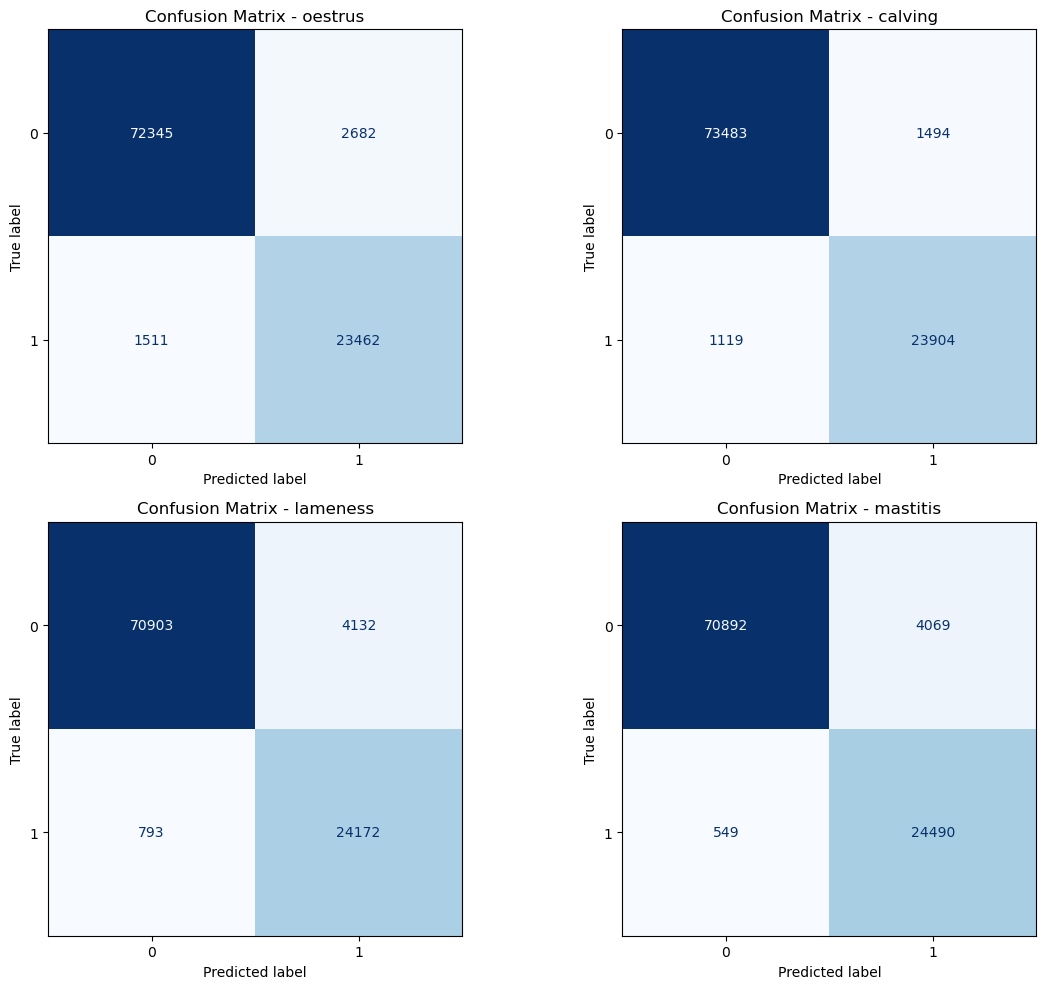

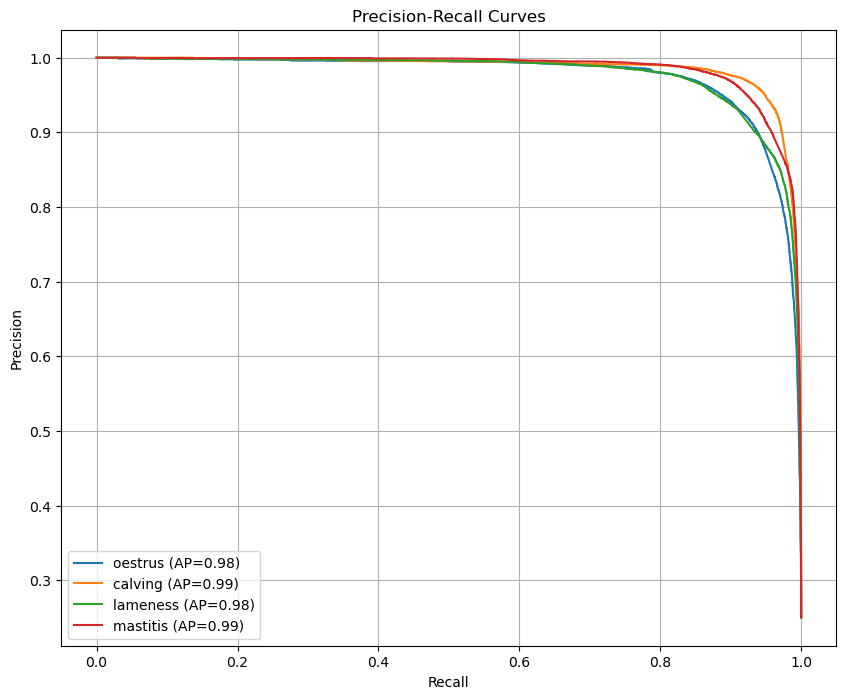

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
import numpy as np
import pandas as pd

# Load model and data
model = joblib.load('rf_multioutput_adasyn_500k.pkl')
df_balanced = pd.read_csv("adasyn_balanced_reduced_500k.csv")

targets = ['oestrus', 'calving', 'lameness', 'mastitis']
features = ['IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL', 'hour_bin']

X = df_balanced[features]
y = df_balanced[targets]

# Split (same as training)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Predictions and probabilities
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Ensure y_prob is in correct structure (list of arrays)
# MultiOutputClassifier stores predict_proba as list of (n_targets) elements
if isinstance(y_prob, list):
    probs_list = y_prob
else:
    probs_list = [y_prob]

# --- 1. Confusion matrices ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, target in enumerate(targets):
    cm = confusion_matrix(y_test[target], y_pred[:, idx])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(f"Confusion Matrix - {target}")

plt.tight_layout()
plt.show()

# --- 2. Precision-Recall curves ---
plt.figure(figsize=(10, 8))

for idx, target in enumerate(targets):
    # Take probability for class 1 from predict_proba for this target
    probs = probs_list[idx][:, 1]
    precision, recall, _ = precision_recall_curve(y_test[target], probs)
    ap = average_precision_score(y_test[target], probs)
    plt.plot(recall, precision, label=f'{target} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid()
plt.show()
